This notebook explores the intricacies of using chemical potential as integral observations to constrain GPs

In [2]:
import sys
import os

current_dir = os.path.dirname(os.path.abspath(''))
others_path = os.path.join(current_dir, '..', '..', 'gpr')

others_path = os.path.abspath(others_path)
if others_path not in sys.path:
    sys.path.append(others_path)

import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Callable
import cvxpy as cp
import matplotlib.cm as cm
import matplotlib.colors as mcolors

from eos import EosProperties
from kernels import Kernel
import gaussianprocess
from constrainedgp import CGP
import finitedimensionalgp as fdgp
import sampling as sam
import prepare_ceft as pc
import prepare_pqcd as pp
import anal_helpers as anal
from pqcd.pQCD import pQCD
from constants import get_phi, ns
import tmg_samplers as tmg
import constrain_on_chempot as coc

from pathlib import Path
notebook_dir = Path.cwd()

from scipy.linalg import cholesky, solve_triangular, cho_solve
from scipy.stats import norm
import scipy as sp
import pandas as pd


from aquarel import load_theme
theme = (
        load_theme("gruvbox_dark")
        .set_font("serif")
        .set_grid(True, width=0.2)
        )

theme.apply()

In [3]:
n_test_test = anal.get_n_test(45,400)

n_ceft, cs2_ceft, cs2_l, cs2_u = anal.get_ceft_cs2()
_, e_ceft, e_ceft_l, e_ceft_u = anal.get_ceft("epsilon")
_, p_ceft, p_ceft_l, p_ceft_u = anal.get_ceft("pressure")

mu_grid = np.linspace(2.6, 2.75, 10)


In [4]:
def plot_comparisons(variant1, variant2):
    v1 = np.load(f"/home/sam/thesis/code/results/eos_samples/{variant1}/test3_eos.npy")
    v2 = np.load(f"/home/sam/thesis/code/results/eos_samples/{variant2}/test3_eos.npy")

    enden_eps_mean = np.nanmean(v1[0], axis=0)
    enden_eps_p5 = np.nanpercentile(v1[0], 0.0, axis=0)
    enden_eps_p95 = np.nanpercentile(v1[0], 100.0, axis=0)

    enden_noeps_mean = np.nanmean(v2[0], axis=0)
    enden_noeps_p5 = np.nanpercentile(v2[0], 0.0, axis=0)
    enden_noeps_p95 = np.nanpercentile(v2[0], 100.0, axis=0)

    press_eps_mean = np.nanmean(v1[1], axis=0)
    press_eps_p5 = np.nanpercentile(v1[1], 0.0, axis=0)
    press_eps_p95 = np.nanpercentile(v1[1], 100.0, axis=0)

    press_noeps_mean = np.nanmean(v2[1], axis=0)
    press_noeps_p5 = np.nanpercentile(v2[1], 0.0, axis=0)
    press_noeps_p95 = np.nanpercentile(v2[1], 100.0, axis=0)

    cs2_eps_mean = np.nanmean(v1[2], axis=0)
    cs2_eps_p5 = np.nanpercentile(v1[2], 0.0, axis=0)
    cs2_eps_p95 = np.nanpercentile(v1[2], 100.0, axis=0)

    cs2_noeps_mean = np.nanmean(v2[2], axis=0)
    cs2_noeps_p5 = np.nanpercentile(v2[2], 0.0, axis=0)
    cs2_noeps_p95 = np.nanpercentile(v2[2], 100.0, axis=0)


    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))


    array = np.geomspace(1/2, 2, 100)
    norm = mcolors.Normalize(vmin=array.min(), vmax=array.max())
    colormap = cm.plasma_r

    for i in np.geomspace(0.5, 2, 100):
        pQCD_temp = pQCD(i)
        edens_qcd = np.vectorize(pQCD_temp.edens)(mu_grid) * 1000
        press_qcd = np.vectorize(pQCD_temp.pressure)(mu_grid) * 1000  

        color = colormap(norm(i)) 
        ax2.plot(edens_qcd, press_qcd, color=color, alpha=0.5)


    sm = cm.ScalarMappable(cmap=colormap, norm=norm)
    sm.set_array(array)  
    cbar = plt.colorbar(sm, ax=plt.gca()) 
    cbar.set_label('Scale Parameter X')
    
    ax2.plot(edens_qcd, press_qcd, 'g', alpha=0.1, label=r"pQCD band")

    ax1.plot(enden_eps_mean, press_eps_mean, label=rf"{variant1} mean")
    ax1.plot(enden_noeps_mean, press_noeps_mean, "-.", color='green', label=rf"{variant2} mean")
    ax1.plot(enden_eps_p5, press_eps_p5, '-.', color='teal')
    ax1.plot(enden_eps_p95, press_eps_p95, '-.', color='teal', label=rf"{variant1} 95th CI")
    ax1.plot(enden_noeps_p5, press_noeps_p5, 'g--')
    ax1.plot(enden_noeps_p95, press_noeps_p95, 'g--', label=rf"{variant2} 95% CI")

    ax2.plot(enden_eps_mean, press_eps_mean, label=rf"{variant1} mean")
    ax2.plot(enden_noeps_mean, press_noeps_mean, "--", color='green', label=rf"{variant2} mean")
    ax2.plot(enden_eps_p5, press_eps_p5, '-.', color='teal')
    ax2.plot(enden_eps_p95, press_eps_p95, '-.', color='teal', label=rf"{variant1} 95th CI")
    ax2.plot(enden_noeps_p5, press_noeps_p5, 'g-.')
    ax2.plot(enden_noeps_p95, press_noeps_p95, 'g-.', label=rf"{variant2} 95% CI")

    ax1.set_xlabel(r'Energy density (MeV/fm$^3$)')
    ax1.set_ylabel(r'Pressure (MeV/fm$^3$)')
    ax1.set_yscale('log')
    ax1.set_xscale('log')
    ax1.set_xlim(50,1e4)
    ax1.set_ylim(0.2,1e4)
    
    ax2.set_xlabel(r'Energy density (MeV/fm$^3$)')
    ax2.set_title("Zoomed into pQCD region")

    ax2.set_xlim(1e4, 1.75e4)
    ax2.set_ylim(2e3, 6e3)

    ax2.legend()
    ax1.legend()

    plt.tight_layout()
    plt.show()


    fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 6))

    ax3.plot(n_test_test, cs2_eps_mean, color='teal', label=rf'{variant1} mean')
    ax3.plot(n_test_test, cs2_noeps_mean, "-.", color='green', label=rf'{variant2} mean')
    ax3.plot(n_test_test, cs2_eps_p5, linestyle='dotted', color='teal')
    ax3.plot(n_test_test, cs2_eps_p95, linestyle='dotted',color='teal', label=rf'{variant1} 95th CI')
    ax3.plot(n_test_test, cs2_noeps_p5, 'g', linestyle='dotted')
    ax3.plot(n_test_test, cs2_noeps_p95, 'g',linestyle='dotted', label=rf'{variant2} 95% CI')
    ax3.set_xlabel(r'Number density (n$_{sat}$)')
    ax3.set_ylabel(r'Sound speed squared ($c_s^2$)')
    ax3.legend()


    ax4.plot(n_test_test, cs2_eps_mean, linestyle='dashdot', color='teal', label=rf'{variant1} mean')
    ax4.plot(n_test_test, cs2_noeps_mean, linestyle='dashdot', color='green', label=rf'{variant2} mean')
    ax4.plot(n_test_test, cs2_eps_p5, linestyle='dotted', color='teal',)
    ax4.plot(n_test_test, cs2_eps_p95, linestyle='dotted', color='teal', label=rf'{variant1} 95th CI')
    ax4.plot(n_test_test, cs2_noeps_p5, 'g', linestyle='dotted')
    ax4.plot(n_test_test, cs2_noeps_p95, 'g', linestyle='dotted', label=rf'{variant2} 95% CI')
    ax4.set_xlabel(r'Number density (n$_{sat}$)')
    ax4.set_ylabel(r'Sound speed squared ($c_s^2$)')
    ax4.set_title("Zoomed into CEFT")
    ax4.plot(n_ceft, cs2_ceft, 'r--', label='CEFT mean')
    ax4.fill_between(n_ceft, cs2_l, cs2_u, color='red', alpha=0.3, label='CEFT 95% CI')
    ax4.set_xlim(0,2)
    ax4.set_ylim(0,0.25)
    ax4.legend()
    plt.tight_layout()

    plt.show()


#### control/test

Uses 100 mu points for conditioning, causality check enabled, lengthscale 1.5-2.0, with error term eps added

### test1

Uses 100 mu points for conditioning, causality check enabled, lengthscale 1.5-2.0, no eps term

### test2
Uses 100 mu points for conditioning, causality check disabled, lengthscale 1.5-2.0, with error term eps added

### test8 
Uses 10 mu points for conditioning, causality check enabled, lengthscale 1.5-2.0, with error term eps added

### test12

Uses 10 mu points for conditioning, causality check enabled, lengthscale 1.5-2.0, with error term eps added, with ln n transformation


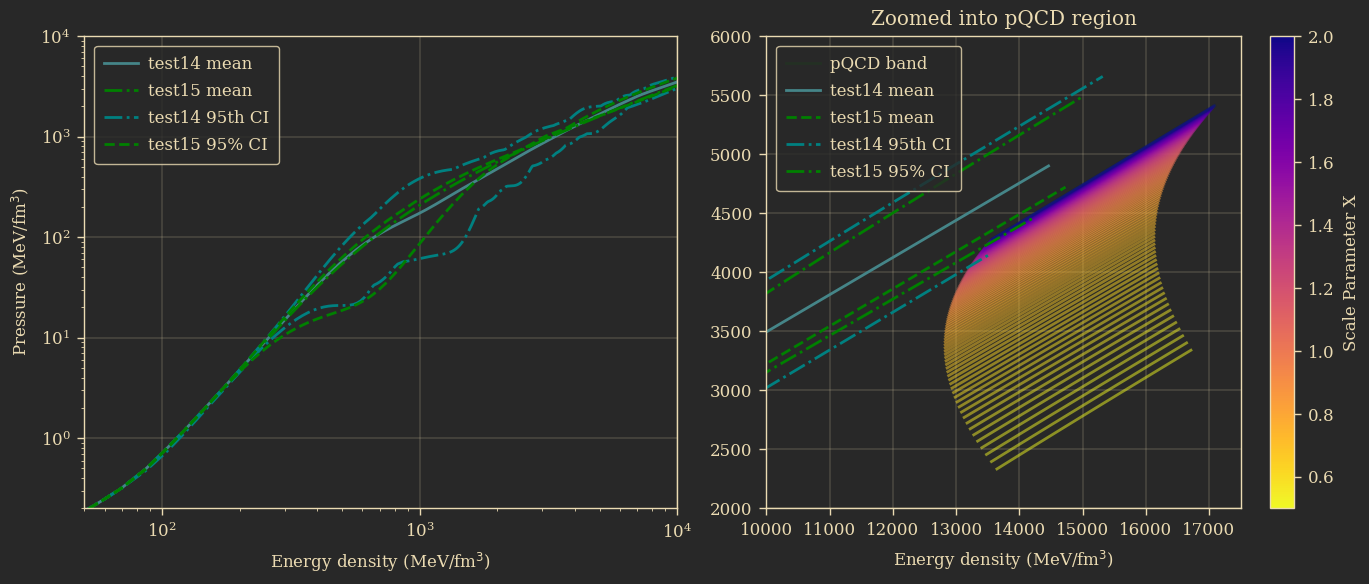

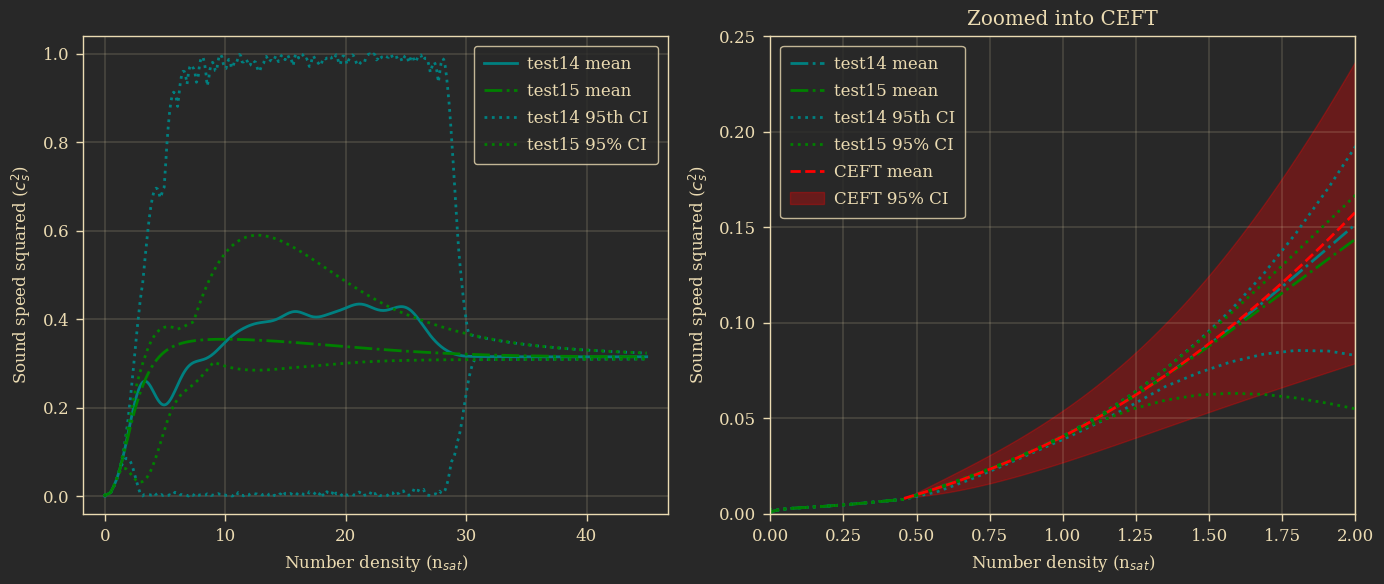

In [19]:
plot_comparisons("test14", "test15")